**11/26/2025**

#GBM MLP Pipeline

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Model Training & Ensemble Evaluation

This section executes the training pipeline across an ensemble of **5 stochastic seeds** to ensure statistical robustness. For each seed, the model undergoes the following protocol:

* **Training Strategy:** Leave-One-Out Cross-Validation (LOOCV) is performed on the training partition (80% of data) to optimize the internal decision boundaries
* **Hold-out Testing:** Final performance is evaluated on a strictly unseen test partition (20% of data) by MLP ensemble.
* **Metrics Tracked:** Accuracy, Balanced Accuracy, Energy Efficiency (FLOPS), and Macro F1-Score are recorded for each iteration.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from pathlib import Path
from collections import Counter
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc, balanced_accuracy_score

# --- 1. SETUP & DATA LOADING ---
SEEDS = [42, 10, 88, 2, 2025]
LABEL_MAP = {0: 'Classical', 1: 'Mesenchymal', 2: 'Neural', 3: 'Proneural'}
base_path = Path("/content/drive/MyDrive/Multimodal_SNN_Protocol_Project/mlp/")

# Load and Combine X_train and X_val for a fair 80% Pool comparison
X_train = pd.read_csv(base_path / "X_train.csv", index_col=0).fillna(-999)
y_train = pd.read_csv(base_path / "y_train.csv", index_col=0)["label"].values
X_val = pd.read_csv(base_path / "X_val.csv", index_col=0).fillna(-999)
y_val = pd.read_csv(base_path / "y_val.csv", index_col=0)["label"].values
X_test = pd.read_csv(base_path / "X_test.csv", index_col=0).fillna(-999)
y_test = pd.read_csv(base_path / "y_test.csv", index_col=0)["label"].values

X_pool = pd.concat([X_train, X_val])
y_pool = np.concatenate([y_train, y_val])

# --- 2. EXECUTION ---
test_visual_data = []
summary_results = []

for seed in SEEDS:
    print(f"Processing Seed {seed}...")
    loo = LeaveOneOut()
    ensemble_preds = []
    ensemble_probas = []

    # Each seed builds an ensemble based on the Combined Pool
    for train_idx, val_idx in loo.split(X_pool):
        mlp = MLPClassifier(hidden_layer_sizes=(32, 16), alpha=0.01, random_state=seed, max_iter=1000)
        mlp.fit(X_pool.iloc[train_idx], y_pool[train_idx])
        ensemble_preds.append(mlp.predict(X_test))
        ensemble_probas.append(mlp.predict_proba(X_test))

    # Aggregate (Majority Vote & Mean Proba)
    y_pred_final = np.array([Counter(np.array(ensemble_preds)[:, i]).most_common(1)[0][0] for i in range(len(X_test))])
    y_proba_final = np.mean(ensemble_probas, axis=0)

    res = {
        'seed': seed,
        'accuracy': accuracy_score(y_test, y_pred_final),
        'f1_macro': f1_score(y_test, y_pred_final, average='macro'),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred_final),
        'y_true': y_test,
        'y_pred': y_pred_final,
        'y_proba': y_proba_final
    }
    test_visual_data.append(res)
    summary_results.append({'Seed': seed, 'Accuracy': res['accuracy'], 'F1 Macro': res['f1_macro'], 'Balanced Acc': res['balanced_accuracy']})

summary_df = pd.DataFrame(summary_results)

# --- 3. CALCULATE ENERGY PROXY ---
d_in = X_pool.shape[1]
ops_per_model = 2 * ((d_in * 32) + (32 * 16) + (16 * 4))
total_flops = ops_per_model * len(X_pool) # Energy for the whole ensemble


Processing Seed 42...
Processing Seed 10...
Processing Seed 88...
Processing Seed 2...
Processing Seed 2025...


Generate metric box/swarm plot, aggregated confusion matrix, and pooled ROC curve to visualize data

/tmp/ipython-input-3161048967.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


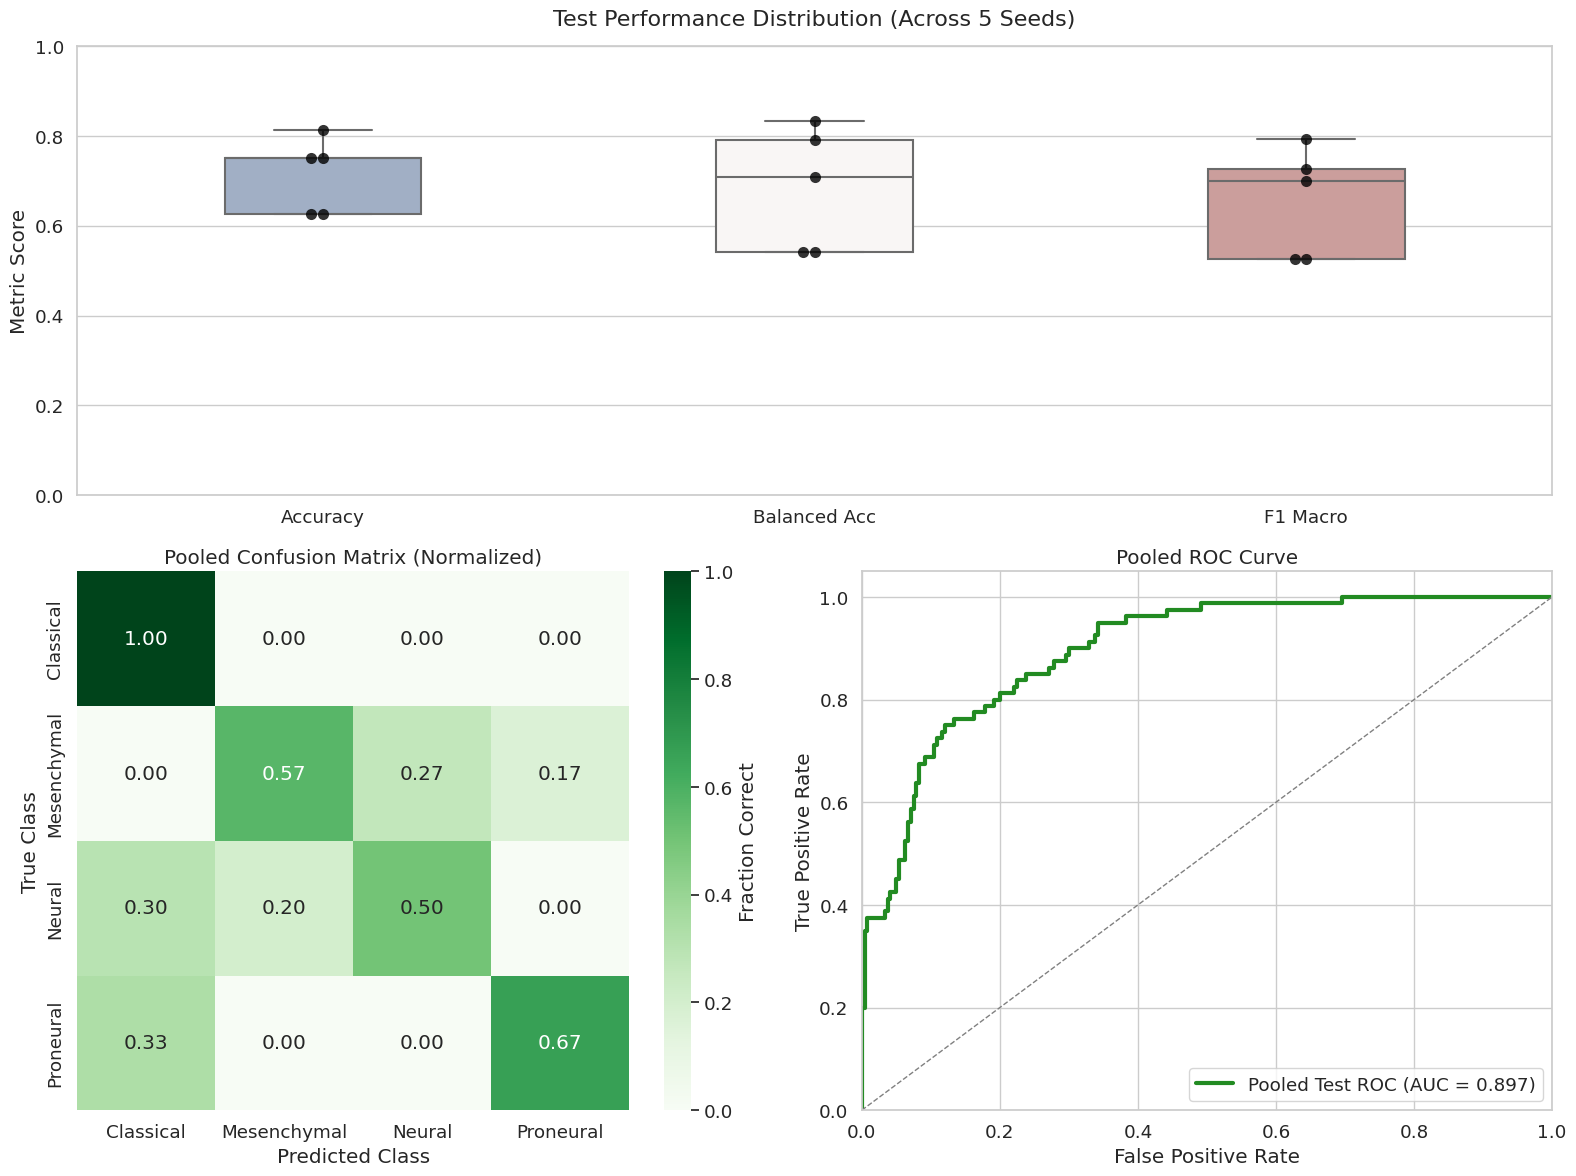

In [ ]:
# --- 4. FINAL AGGREGATED REPORT (MLP PERFORMANCE) ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Setup Aesthetics
sns.set_theme(style="whitegrid", font_scale=1.2)
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# --- DATA POOLING ---
# Combine all results from the 5 seeds into a single "pool"
pooled_y_true = np.concatenate([res['y_true'] for res in test_visual_data])
pooled_y_pred = np.concatenate([res['y_pred'] for res in test_visual_data])
pooled_y_proba = np.concatenate([res['y_proba'] for res in test_visual_data])

# --- 2. PREPARE DATA FOR BOXPLOT ---
# Re-creating summary_df to ensure clean columns for plotting
results_list = []
for res in test_visual_data:
    results_list.append({
        'Seed': res['seed'],
        'Accuracy': res['accuracy'],
        'Balanced Acc': res['balanced_accuracy'],
        'F1 Macro': res['f1_macro']
    })
viz_df = pd.DataFrame(results_list)

# PANEL 1: Boxplot + Swarm with Whiskers & Outliers (0-1 Range)
ax1 = fig.add_subplot(gs[0, :])
melted = viz_df.melt(id_vars=['Seed'], var_name='Metric', value_name='Score')

# Create the styled boxplot (Standard whiskers and median line)
sns.boxplot(
    x='Metric', y='Score', data=melted, ax=ax1,
    width=0.4,
    palette="vlag",
    linewidth=1.5,
    showfliers=True         # Ensure outliers are shown
)

# Overlay the swarm plot (the individual dots for each seed)
sns.swarmplot(
    x='Metric', y='Score', data=melted, ax=ax1,
    color="black", size=8, alpha=0.8
)

# Set title and set Y-axis to full 0-1
ax1.set_title("Test Performance Distribution (Across 5 Seeds)", fontsize=16, pad=15)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel("Metric Score")
ax1.set_xlabel("")

# PANEL 2: Normalized Green Confusion Matrix
ax2 = fig.add_subplot(gs[1, 0])
# Normalize by 'true' labels to get values between 0.0 and 1.0
cm_norm = confusion_matrix(pooled_y_true, pooled_y_pred, normalize='true')

sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=ax2,
    xticklabels=LABEL_MAP.values(), yticklabels=LABEL_MAP.values(),
    vmin=0, vmax=1, cbar_kws={'label': 'Fraction Correct'}
)
ax2.set_title("Pooled Confusion Matrix (Normalized)")
ax2.set_xlabel("Predicted Class")
ax2.set_ylabel("True Class")

# PANEL 3: Single Pooled ROC Curve (One Line)
ax3 = fig.add_subplot(gs[1, 1])

# Binarize labels for micro-average (Single Line)
n_classes = len(LABEL_MAP)
y_test_bin = label_binarize(pooled_y_true, classes=np.arange(n_classes))

# Micro-average flattens all classes and seeds into one pool for one single line
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), pooled_y_proba.ravel())
roc_auc = auc(fpr, tpr)

ax3.plot(fpr, tpr, color='forestgreen', lw=3, label=f'Pooled Test ROC (AUC = {roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_title("Pooled ROC Curve")
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.legend(loc="lower right")

plt.tight_layout()
plt.show()

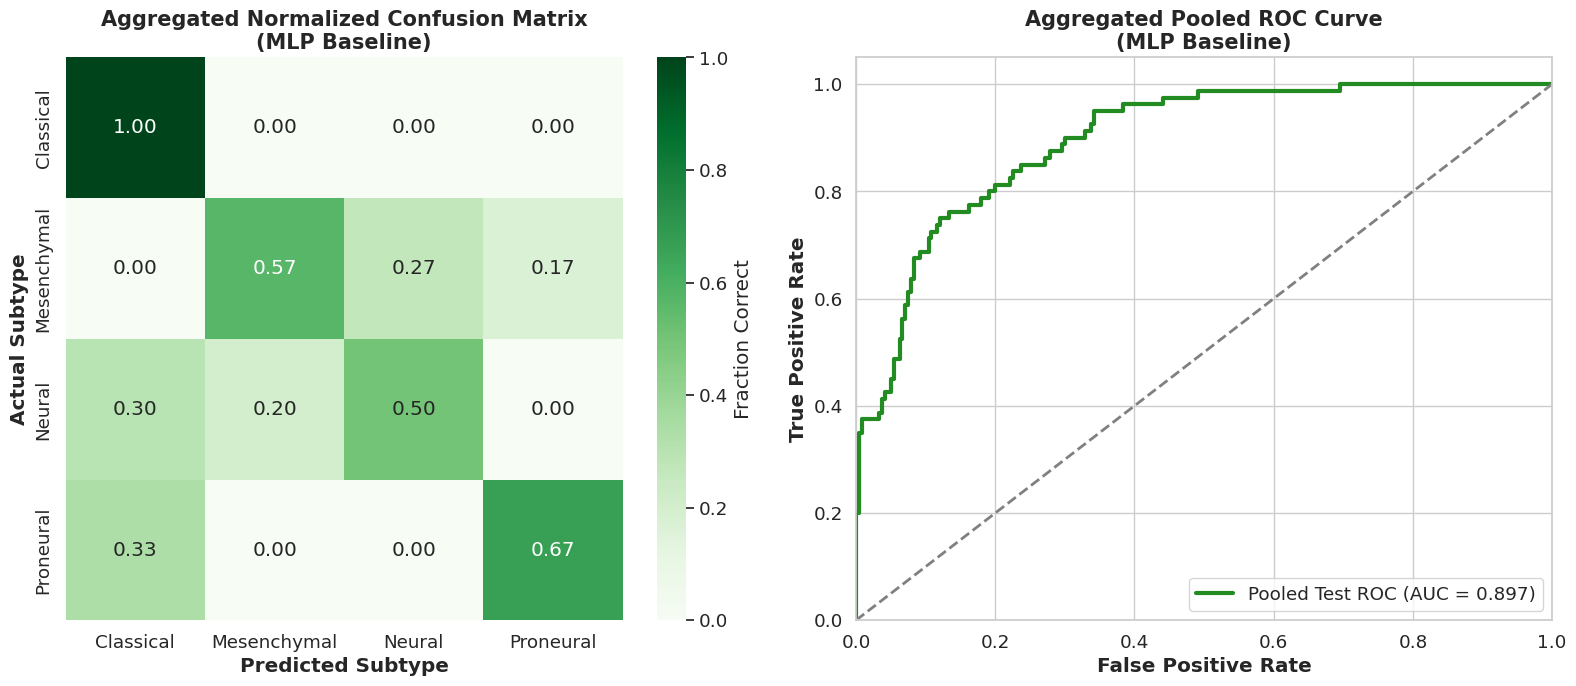

In [ ]:
# --- 4. FINAL AGGREGATED REPORT (MLP PERFORMANCE) ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Setup Aesthetics
sns.set_theme(style="whitegrid", font_scale=1.2)
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# --- DATA POOLING ---
# Combine all results from the 5 seeds into a single "pool"
pooled_y_true = np.concatenate([res['y_true'] for res in test_visual_data])
pooled_y_pred = np.concatenate([res['y_pred'] for res in test_visual_data])
pooled_y_proba = np.concatenate([res['y_proba'] for res in test_visual_data])

# --- 2. PREPARE DATA FOR BOXPLOT ---
# Re-creating summary_df to ensure clean columns for plotting
results_list = []
for res in test_visual_data:
    results_list.append({
        'Seed': res['seed'],
        'Accuracy': res['accuracy'],
        'Balanced Acc': res['balanced_accuracy'],
        'F1 Macro': res['f1_macro']
    })
viz_df = pd.DataFrame(results_list)


# PANEL 2: Normalized Green Confusion Matrix
ax2 = fig.add_subplot(gs[1, 0])
# Normalize by 'true' labels to get values between 0.0 and 1.0
cm_norm = confusion_matrix(pooled_y_true, pooled_y_pred, normalize='true')

sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=ax2,
    xticklabels=LABEL_MAP.values(), yticklabels=LABEL_MAP.values(),
    vmin=0, vmax=1, cbar_kws={'label': 'Fraction Correct'}
)
ax2.set_title("Aggregated Normalized Confusion Matrix\n(MLP Baseline)", fontsize=15, fontweight='bold')
ax2.set_xlabel("Predicted Subtype", fontweight='bold')
ax2.set_ylabel("Actual Subtype",fontweight='bold')

# PANEL 3: Single Pooled ROC Curve (One Line)
ax3 = fig.add_subplot(gs[1, 1])

# Binarize labels for micro-average (Single Line)
n_classes = len(LABEL_MAP)
y_test_bin = label_binarize(pooled_y_true, classes=np.arange(n_classes))

# Micro-average flattens all classes and seeds into one pool for one single line
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), pooled_y_proba.ravel())
roc_auc = auc(fpr, tpr)

ax3.plot(fpr, tpr, color='forestgreen', lw=3, label=f'Pooled Test ROC (AUC = {roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate',fontweight='bold')
ax3.set_ylabel('True Positive Rate',fontweight='bold')
ax3.set_title('Aggregated Pooled ROC Curve\n(MLP Baseline)', fontsize=15, fontweight='bold')
ax3.legend(loc="lower right")

plt.tight_layout()
plt.show()